In [2]:
import xarray as xr
import earthkit.data
import earthkit.plots
import earthkit.regrid
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
request = {
     'activity': 'ScenarioMIP',
     'class': 'd1',
     'dataset': 'climate-dt',
     'date': '20200101',
     'experiment': 'SSP3-7.0',
     'expver': '0001',
     'generation': '1',
     'levtype': 'sfc',
     'model': 'IFS-NEMO',
     'param': '263000',
     'realization': '1',
     'resolution': 'standard',
     'stream': 'clte',
     'time': '0000', # '0100/0200/0300/0400/0500/0600'
     'type': 'fc'
 }

In [4]:
# Base request template
request_silvl = {
    'activity': 'ScenarioMIP',
    'class': 'd1',
    'dataset': 'climate-dt',
    'date': '20200101/to/20200102',
    'experiment': 'SSP3-7.0',
    'expver': '0001',
    'generation': '1',
    'levtype': 'o2d',
    'model': 'IFS-NEMO',
    'param': '263000',
    'realization': '1',
    'resolution': 'high',
    'stream': 'clte',
    'time': '0000',
    'type': 'fc'
}

In [ ]:
# Download the data from the datalake
data = earthkit.data.from_source("polytope", "destination-earth", request_silvl, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)

# Remap the data on a regular grid 0.1° x 0.1°
out_grid = {"grid": [0.1,0.1]}
r = earthkit.regrid.interpolate(data, out_grid=out_grid, method="linear")
d = r.data()
lat = d[0]
lon = d[1]
vals = d[2:]
lat.shape, lon.shape, vals.shape

# Convert to xarray
ds = r.to_xarray().rename({"forecast_reference_time": "time"})
ds

# Now that we have the data...
We can play with the data:
- Check the average sea-ice thickness

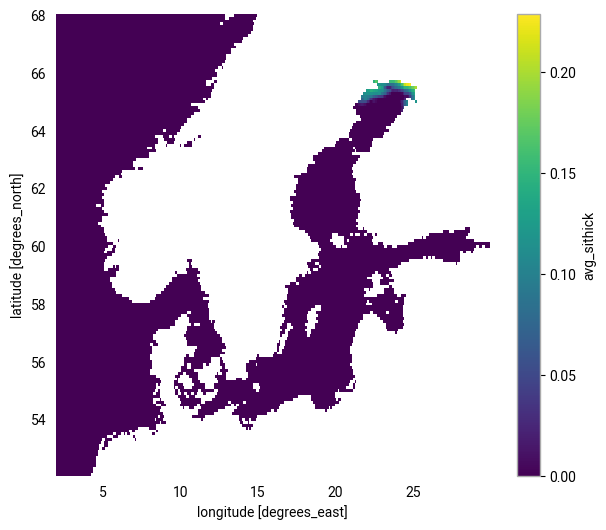

In [ ]:
ds.avg_sithick.sel(time=0).isel(latitude=slice(220,380)).isel(longitude=slice(20,300)).plot()